In [206]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

In [209]:
from anomaly_detection.models.SVDD_AE_low_no_bias import AE_low

In [210]:
from anomaly_detection.config.paths import CHECKPOINT_DIR

checkpoint = torch.load(os.path.join(CHECKPOINT_DIR, "CURRENT_SVDD_no_bn_lam=10e-6_noBias_train_date=22-03_18-42", "SVDD_no_bn_lam=10e-6_noBias_ep248.pth"), map_location="cpu")

config = checkpoint["config"]

model = AE_low()
model.load_state_dict(checkpoint["model_state_dict"])

model.eval()

AE_low(
  (encoder): Sequential(
    (0): Conv1d(1, 4, kernel_size=(4,), stride=(2,), padding=(1,), bias=False)
    (1): ReLU()
    (2): Conv1d(4, 8, kernel_size=(4,), stride=(2,), padding=(1,), bias=False)
    (3): ReLU()
    (4): Conv1d(8, 12, kernel_size=(2,), stride=(1,), bias=False)
    (5): ReLU()
    (6): Conv1d(12, 16, kernel_size=(6,), stride=(1,), bias=False)
    (7): Sigmoid()
  )
  (decoder): Sequential(
    (0): ConvTranspose1d(16, 12, kernel_size=(6,), stride=(1,), bias=False)
    (1): ReLU()
    (2): ConvTranspose1d(12, 8, kernel_size=(2,), stride=(1,), bias=False)
    (3): ReLU()
    (4): ConvTranspose1d(8, 4, kernel_size=(4,), stride=(2,), padding=(1,), bias=False)
    (5): ReLU()
    (6): ConvTranspose1d(4, 1, kernel_size=(4,), stride=(2,), padding=(1,), bias=False)
    (7): Sigmoid()
  )
)

In [211]:
from anomaly_detection.utils.load_sam_data import load_dataset
from anomaly_detection.utils.preprocess import drop_empty_histograms
from anomaly_detection.utils.preprocess import minmax_scale_per_sample

dataset = load_dataset("FJ")
full_dataset = np.array(dataset)
full_dataset = minmax_scale_per_sample(full_dataset)

dataset_no_outs = drop_empty_histograms(full_dataset)

Loading data from: C:\Users\hrdyj\coding\vyzkumak\data\FJ\FI01X1\FI01X1_ch
Dropped indexes [8, 15, 188, 214, 263, 268, 533, 546]


In [212]:
from anomaly_detection.utils.autoencoders import HistDataset
full_dataset = HistDataset(full_dataset)

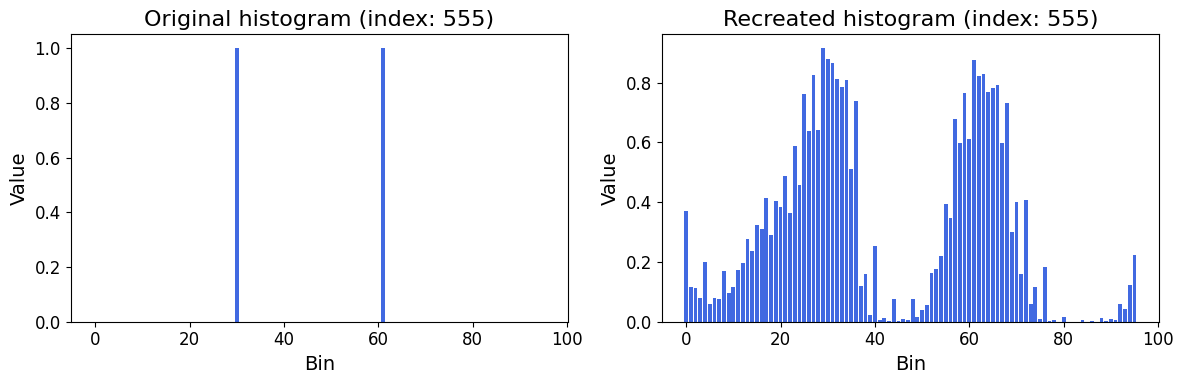

In [213]:
from anomaly_detection.utils.inspect_hist import plot_original_and_reconstructed

plot_original_and_reconstructed(model, full_dataset, idx=555)

In [214]:
from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(dataset_no_outs, shuffle=True, train_size=0.8, random_state=42)

In [215]:
pt = torch.tensor(full_dataset[0]).reshape(1,1,96)
model.eval()
x = model.encoder(pt)
print(x.shape)
print(torch.flatten(x).shape)

torch.Size([1, 16, 18])
torch.Size([288])


C:\Users\hrdyj\AppData\Local\Temp\ipykernel_18136\56861300.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  pt = torch.tensor(full_dataset[0]).reshape(1,1,96)


In [216]:
# center calculation
model.eval()
embeddings = []

with torch.no_grad():  
    for data in X_train:
        data_tensor = torch.as_tensor(data, dtype=torch.float32).reshape(1, 1, 96)
        
        embed = model.encoder(data_tensor)
        
        embeddings.append(embed.flatten())

embeddings_stack = torch.stack(embeddings)
center = torch.mean(embeddings_stack, dim=0)

Text(0.5, 1.0, 'Computed center of the hypersphere')

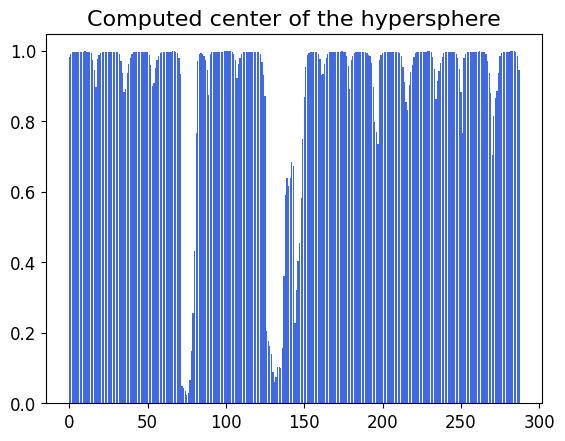

In [217]:
plt.bar(range(len(center)), center, color='royalblue')
plt.title("Computed center of the hypersphere")

In [218]:
def score_svdd(df, encoder, center=center):
    scores = []
    with torch.no_grad():
        for pt in df:
            if not type(pt) == torch.Tensor:
                pt = torch.tensor(pt)
            pt = torch.flatten(encoder(pt.reshape(1,1,96)).detach())
            scores.append(torch.sum((pt-center)**2))
    return scores

In [219]:
scores = score_svdd(full_dataset, model.encoder, center)
eval_score = score_svdd(eval_df, model.encoder, center)

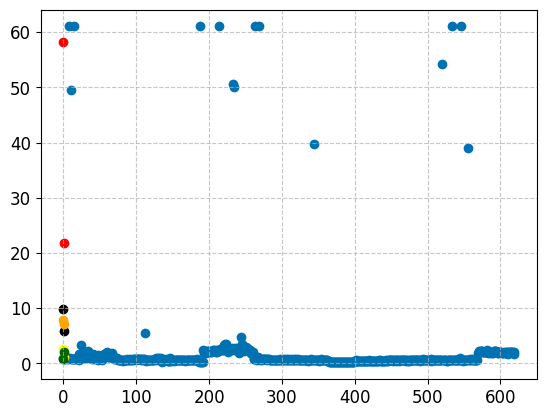

In [220]:
import matplotlib.pyplot as plt
from anomaly_detection.utils.plotting_styles import apply_global_style
apply_global_style()
plt.scatter(range(len(scores)), scores)
plt.scatter(range(len(eval_score[:2])), eval_score[:2], color='black', label='Random')
plt.scatter(range(len(eval_score[2:4])), eval_score[2:4], color='red', label='Strong')
plt.scatter(range(len(eval_score[4:6])), eval_score[4:6], color='orange', label='Medium')
plt.scatter(range(len(eval_score[6:8])), eval_score[6:8], color='yellow', label='Weak')
plt.scatter(range(len(eval_score[8:])), eval_score[8:], color='darkgreen', label='Normal')

In [221]:
from torch.utils.data import DataLoader
from anomaly_detection.utils.autoencoders import HistDataset
from anomaly_detection.utils.losses import HyperSphereLoss

batch_size = 32
train_dataset = HistDataset(X_train)
test_dataset = HistDataset(X_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

criterion = HyperSphereLoss(center=center)
lam = 10e-6

n_epochs = 250
optimizer = torch.optim.Adam(params=model.encoder.parameters(), lr=0.000005)

In [ ]:
from anomaly_detection.config import paths
import time

model.train()

saving_after_epoch = 30
model_name = "CURRENT_SVDD_part_2"
folder_name_for_checkpoints = f"{model_name}_train_date={time.strftime("%d-%m_%H-%M")}"

train_losses = []
val_losses = []

train_loader_length = len(train_loader)
test_loader_length = len(test_loader)

minimal_val_loss = float('inf')

for ep in range(n_epochs):
    train_loss = 0.0
    validation_loss = 0.0

    for x in train_loader:
        embed = model.encoder(x)
        embed = embed.view(x.size(0), -1)
        
        loss = criterion(embed) + lam * sum(p.pow(2).sum() for p in model.encoder.parameters())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
    model.eval()
    with torch.no_grad():
        for x in test_loader:
            val_embed = model.encoder(x)
            val_embed = val_embed.view(x.size(0), -1)
            
            val_loss = criterion(val_embed)
            
            validation_loss += val_loss.item()

    val_loss = validation_loss/test_loader_length
    loss = train_loss/train_loader_length
    model.train()

    train_losses.append(loss)
    val_losses.append(val_loss)

    
    if True and ep > saving_after_epoch:
            if val_loss < minimal_val_loss:
                os.makedirs(os.path.join(paths.CHECKPOINT_DIR,folder_name_for_checkpoints), exist_ok=True)
                torch.save({
                    "model_state_dict": model.state_dict(),
                    "config": {
                        "input_dim": 96,
                        "latent_dim": 7,
                    },
                    "val_loss": val_loss
                }, f"{os.path.join(paths.CHECKPOINT_DIR, folder_name_for_checkpoints)}/{model_name}_ep{ep}.pth")
                print(f"[Checkpoint created] saved weights in epoch: {ep}")
                minimal_val_loss = min(val_losses) if len(val_losses) > 0 else val_loss

    if ep % 20 == 0:
        print(f"Ep: {ep} train_loss: {loss} validation loss: {val_loss}")
        

Ep: 0 train_loss: 1.3210702911019325
Ep: 20 train_loss: 1.2806696183979511
[Checkpoint created] saved weights in epoch: 31
[Checkpoint created] saved weights in epoch: 32
[Checkpoint created] saved weights in epoch: 33
[Checkpoint created] saved weights in epoch: 34
[Checkpoint created] saved weights in epoch: 35
[Checkpoint created] saved weights in epoch: 36
[Checkpoint created] saved weights in epoch: 37
[Checkpoint created] saved weights in epoch: 38
[Checkpoint created] saved weights in epoch: 39
[Checkpoint created] saved weights in epoch: 40
Ep: 40 train_loss: 1.2411868013441563
[Checkpoint created] saved weights in epoch: 41
[Checkpoint created] saved weights in epoch: 42
[Checkpoint created] saved weights in epoch: 43
[Checkpoint created] saved weights in epoch: 44
[Checkpoint created] saved weights in epoch: 45
[Checkpoint created] saved weights in epoch: 46
[Checkpoint created] saved weights in epoch: 47
[Checkpoint created] saved weights in epoch: 48
[Checkpoint created] sa

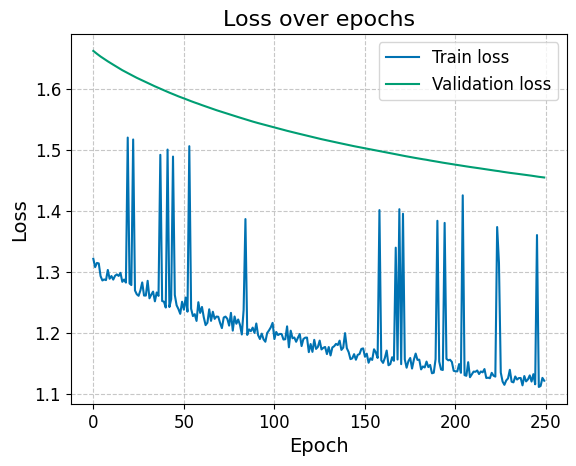

In [234]:
apply_global_style()
plt.title("Loss over epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.plot(range(len(train_losses)), train_losses, label='Train loss')
plt.plot(range(len(val_losses)), val_losses, label='Validation loss')
plt.legend()
plt.show()

In [224]:
min(val_losses)

1.4543602764606476

In [225]:
val_losses = np.array(val_losses)
np.where(val_losses == min(val_losses))

(array([249]),)

In [226]:
full_dataset = HistDataset(full_dataset)

In [227]:
import pandas as pd 
from anomaly_detection.config.paths import DATA_DIR
import os

eval_df = pd.read_parquet(os.path.join(DATA_DIR, 'eval_data', 'eval_dataset.parquet'))
eval_df = HistDataset(eval_df['histogram'].values)

In [228]:
def score_svdd(df, encoder):
    scores = []
    with torch.no_grad():
        for pt in df:
            if not type(pt) == torch.Tensor:
                pt = torch.tensor(pt)
            pt = torch.flatten(encoder(pt.reshape(1,1,96)).detach())
            scores.append(torch.sum((pt-center)**2))
    return scores

In [229]:
scores = []
with torch.no_grad():
    for pt in full_dataset:
        if not type(pt) == torch.Tensor:
            pt = torch.tensor(pt) 
        pt = torch.flatten(model.encoder(pt.reshape(1,1,96)).detach())
        scores.append(torch.sum((pt-center)**2))

In [230]:
scores = score_svdd(full_dataset, model.encoder)

In [231]:
eval_score = score_svdd(eval_df, model.encoder)

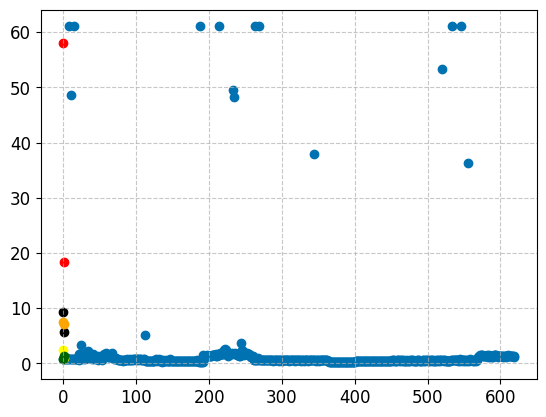

In [232]:
import matplotlib.pyplot as plt
from anomaly_detection.utils.plotting_styles import apply_global_style
apply_global_style()
plt.scatter(range(len(scores)), scores)
plt.scatter(range(len(eval_score[:2])), eval_score[:2], color='black', label='Random')
plt.scatter(range(len(eval_score[2:4])), eval_score[2:4], color='red', label='Strong')
plt.scatter(range(len(eval_score[4:6])), eval_score[4:6], color='orange', label='Medium')
plt.scatter(range(len(eval_score[6:8])), eval_score[6:8], color='yellow', label='Weak')
plt.scatter(range(len(eval_score[8:])), eval_score[8:], color='darkgreen', label='Normal')

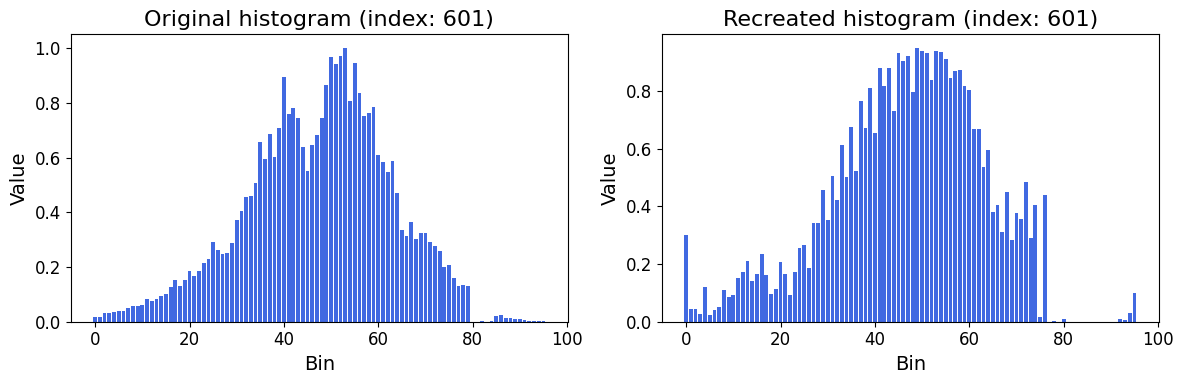

In [233]:
plot_original_and_reconstructed(model, full_dataset, idx=601)